In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.20.0


In [3]:
from google.colab import files

uploaded = files.upload()

Saving mnist_test.csv to mnist_test (2).csv
Saving mnist_train.csv to mnist_train.csv


In [4]:
train_df = pd.read_csv('/content/mnist_train.csv')
test_df = pd.read_csv('/content/mnist_test.csv')

print("Training Dataset Shape:", train_df.shape)
print("Testing Dataset Shape:", test_df.shape)

/tmp/ipykernel_451/1741870786.py:1: DtypeWarning: Columns (0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,120,121,122,123,124,125,126,127,128,129,130,131,132,133,134,135,136,137,138,139,140,141,142,143,144,145,146,147,148,149,150,151,152,153,154,155,156,157,158,159,160,161,162,163,164,165,166,167,168,169,170,171,172,173,174,175,176,177,178,179,180,181,182,183,184,185,186,187,188,189,190,191,192,193,194,195,196,197,198,199,200,201,202,203,204,205,206,207,208,209,210,211,212,213,214,215,216,217,218,219,220,221,222,223,224,225,226,227,228,229,230,231,232,233,234,235,236,237,238,239,240,241,242,243,244,245,246,247,248,249,250,251,252,253,254,255,256,257,258,259,260,261,262

Training Dataset Shape: (60001, 785)
Testing Dataset Shape: (10001, 785)


/tmp/ipykernel_451/1741870786.py:2: DtypeWarning: Columns (0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,120,121,122,123,124,125,126,127,128,129,130,131,132,133,134,135,136,137,138,139,140,141,142,143,144,145,146,147,148,149,150,151,152,153,154,155,156,157,158,159,160,161,162,163,164,165,166,167,168,169,170,171,172,173,174,175,176,177,178,179,180,181,182,183,184,185,186,187,188,189,190,191,192,193,194,195,196,197,198,199,200,201,202,203,204,205,206,207,208,209,210,211,212,213,214,215,216,217,218,219,220,221,222,223,224,225,226,227,228,229,230,231,232,233,234,235,236,237,238,239,240,241,242,243,244,245,246,247,248,249,250,251,252,253,254,255,256,257,258,259,260,261,262

In [5]:
train_df.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,label,1x1,1x2,1x3,1x4,1x5,1x6,1x7,1x8,1x9,...,28x19,28x20,28x21,28x22,28x23,28x24,28x25,28x26,28x27,28x28
1,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [6]:
print("Training Dataset Information:")
train_df.info()

Training Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60001 entries, 0 to 60000
Columns: 785 entries, label to pixel784
dtypes: object(785)
memory usage: 359.4+ MB


In [7]:
print("Missing Values:")
print(train_df.isnull().sum().sum())

Missing Values:
0


In [9]:
print("Digit Distribution:")
# The first row of train_df contains the column names as data, leading to mixed types in 'label' column.
# Exclude the first row and convert the 'label' column to numeric for correct sorting.
cleaned_train_df = train_df.iloc[1:].copy()
cleaned_train_df['label'] = pd.to_numeric(cleaned_train_df['label'])
print(cleaned_train_df['label'].value_counts().sort_index())

Digit Distribution:
label
0    5923
1    6742
2    5958
3    6131
4    5842
5    5421
6    5918
7    6265
8    5851
9    5949
Name: count, dtype: int64


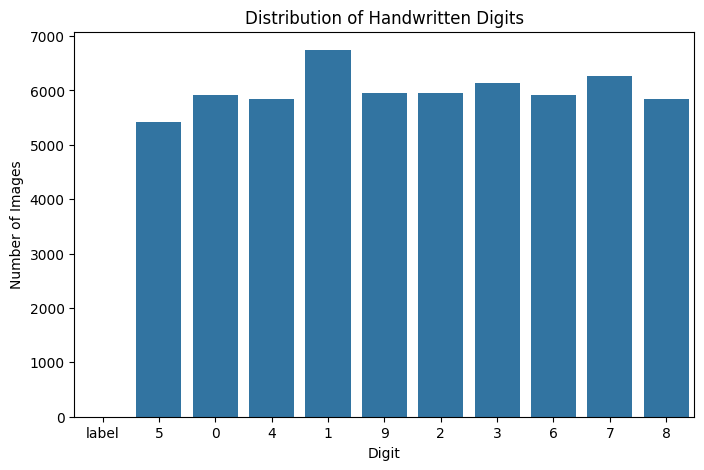

In [10]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=train_df,
    x='label'
)

plt.title('Distribution of Handwritten Digits')
plt.xlabel('Digit')
plt.ylabel('Number of Images')
plt.show()

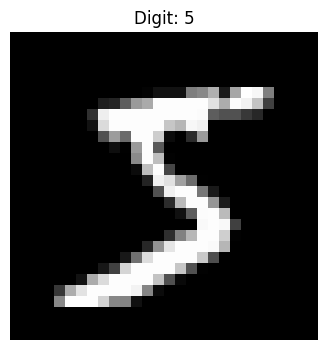

In [12]:
# The original train_df has its first row as column names, causing the issue.
# We need to skip the header row and ensure the pixel data is numeric.

# Get the first actual image row (index 1) from train_df
# and drop the 'label' column. Convert the pixel values to a numeric type.
X_sample = train_df.iloc[1].drop('label').values.astype(np.float32)

# The corresponding label for the first actual image is also at index 1
digit_label = train_df['label'].iloc[1]

plt.figure(figsize=(4, 4))

plt.imshow(
    X_sample.reshape(28, 28),
    cmap='gray'
)

plt.title(f"Digit: {digit_label}")
plt.axis('off')
plt.show()

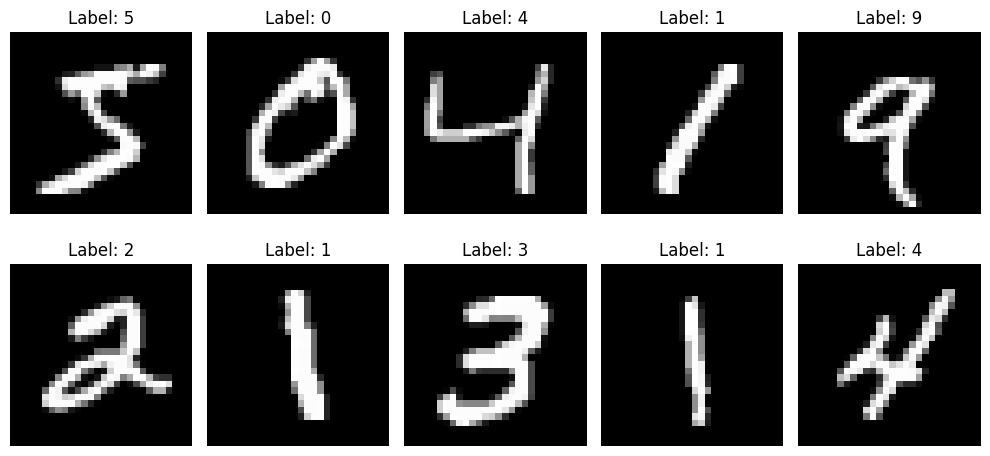

In [14]:
plt.figure(figsize=(10, 5))

# Start from index 1 to skip the header row, and iterate for the first 10 actual images
for i in range(1, 11):
    plt.subplot(2, 5, i)

    # Select the image data and convert pixel values to a float type
    image = train_df.drop('label', axis=1).iloc[i].values.astype(np.float32)
    label = train_df['label'].iloc[i]

    plt.imshow(image.reshape(28, 28), cmap='gray')
    plt.title(f"Label: {label}")
    plt.axis('off')

plt.tight_layout()
plt.show()

In [15]:
X = train_df.drop('label', axis=1).values
y = train_df['label'].values

print("Feature Shape:", X.shape)
print("Label Shape:", y.shape)

Feature Shape: (60001, 784)
Label Shape: (60001,)


In [18]:
# The first row of X contains string headers, causing the ValueError.
# We need to exclude the header row before converting to float.
X = X[1:].astype('float32') / 255.0

In [19]:
X = X.reshape(-1, 28, 28, 1)

print("Reshaped Image Data:", X.shape)

Reshaped Image Data: (59999, 28, 28, 1)


In [21]:
# The error occurs because X and y have inconsistent numbers of samples.
# X was already sliced to exclude the header, and it appears to have been sliced twice,
# resulting in 59999 samples. y still contains the header and all 60001 samples.
# We need to slice y to match the number of samples in X and convert its type.

# Slice y to exclude the first two elements to match the 59999 samples in X,
# and convert to integer type for labels.
y = y[2:].astype(np.int32)

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Data:", X_train.shape)
print("Validation Data:", X_val.shape)

Training Data: (47999, 28, 28, 1)
Validation Data: (12000, 28, 28, 1)


## Convolutional Neural Network (CNN)

A Convolutional Neural Network (CNN) is used to recognize handwritten digits.
The CNN automatically learns important image features such as edges, curves,
and shapes from the 28×28 grayscale images.

The model consists of convolutional layers, pooling layers, a fully connected
layer, and an output layer with 10 neurons representing digits 0–9.

In [22]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout

# Build CNN model
model = Sequential([

    # First Convolutional Layer
    Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    MaxPooling2D((2, 2)),

    # Second Convolutional Layer
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),

    # Convert feature maps into a single vector
    Flatten(),

    # Fully Connected Layer
    Dense(128, activation='relu'),

    # Dropout to reduce overfitting
    Dropout(0.5),

    # Output Layer - 10 classes (0 to 9)
    Dense(10, activation='softmax')
])

# Display model architecture
model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [24]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("CNN model compiled successfully!")

CNN model compiled successfully!


In [25]:
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=128,
    validation_data=(X_val, y_val),
    verbose=1
)

Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 41s 104ms/step - accuracy: 0.5098 - loss: 1.4259 - val_accuracy: 0.8671 - val_loss: 0.4608
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 41s 110ms/step - accuracy: 0.8316 - loss: 0.5431 - val_accuracy: 0.9050 - val_loss: 0.3072
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 39s 103ms/step - accuracy: 0.8778 - loss: 0.4027 - val_accuracy: 0.9336 - val_loss: 0.2236
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 39s 103ms/step - accuracy: 0.9033 - loss: 0.3222 - val_accuracy: 0.9477 - val_loss: 0.1708
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 41s 103ms/step - accuracy: 0.9193 - loss: 0.2681 - val_accuracy: 0.9548 - val_loss: 0.1512
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 37s 98ms/step - accuracy: 0.9289 - loss: 0.2372 - val_accuracy: 0.9591 - val_loss: 0.1314
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 42s 101ms/step - accuracy: 0.9364 - loss: 0.2122 - val_accuracy: 0.9635 - val_loss: 0.1207
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 43s 106ms/step - accuracy: 0.9405 - loss: 0.

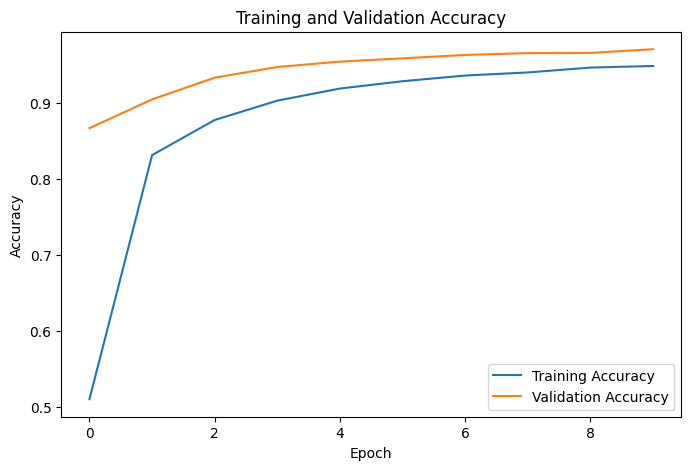

In [26]:
plt.figure(figsize=(8, 5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

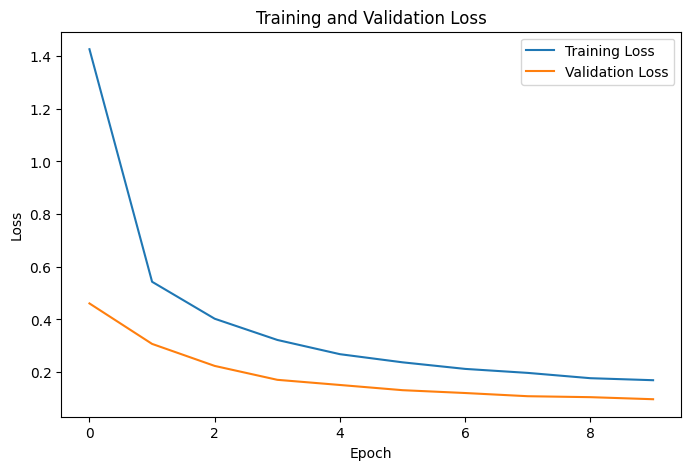

In [27]:
plt.figure(figsize=(8, 5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [28]:
test_loss, test_accuracy = model.evaluate(X_val, y_val, verbose=0)

print("CNN Evaluation")
print("----------------")
print("Validation Loss    :", round(test_loss, 4))
print("Validation Accuracy:", round(test_accuracy, 4))

CNN Evaluation
----------------
Validation Loss    : 0.0971
Validation Accuracy: 0.9711


In [30]:
y_pred_prob = model.predict(X_val)

y_pred = np.argmax(y_pred_prob, axis=1)

print("Predictions generated successfully!")

375/375 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step
Predictions generated successfully!


## Confusion Matrix

The confusion matrix shows the number of correctly and incorrectly classified
images for each handwritten digit from 0 to 9.

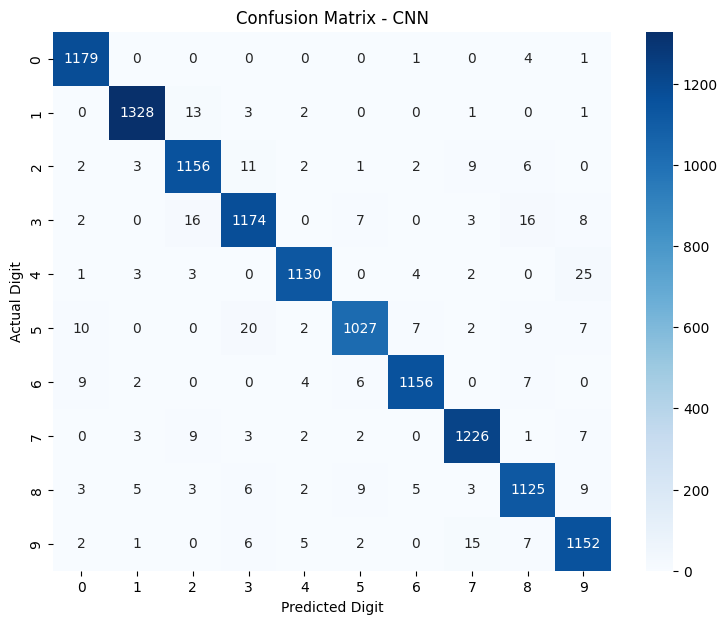

In [31]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_val, y_pred)

plt.figure(figsize=(9, 7))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=range(10),
    yticklabels=range(10)
)

plt.xlabel('Predicted Digit')
plt.ylabel('Actual Digit')
plt.title('Confusion Matrix - CNN')
plt.show()

In [32]:
from sklearn.metrics import classification_report

print("Classification Report - CNN")
print("--------------------------------")

print(
    classification_report(
        y_val,
        y_pred,
        target_names=[str(i) for i in range(10)]
    )
)

Classification Report - CNN
--------------------------------
              precision    recall  f1-score   support

           0       0.98      0.99      0.99      1185
           1       0.99      0.99      0.99      1348
           2       0.96      0.97      0.97      1192
           3       0.96      0.96      0.96      1226
           4       0.98      0.97      0.98      1168
           5       0.97      0.95      0.96      1084
           6       0.98      0.98      0.98      1184
           7       0.97      0.98      0.98      1253
           8       0.96      0.96      0.96      1170
           9       0.95      0.97      0.96      1190

    accuracy                           0.97     12000
   macro avg       0.97      0.97      0.97     12000
weighted avg       0.97      0.97      0.97     12000



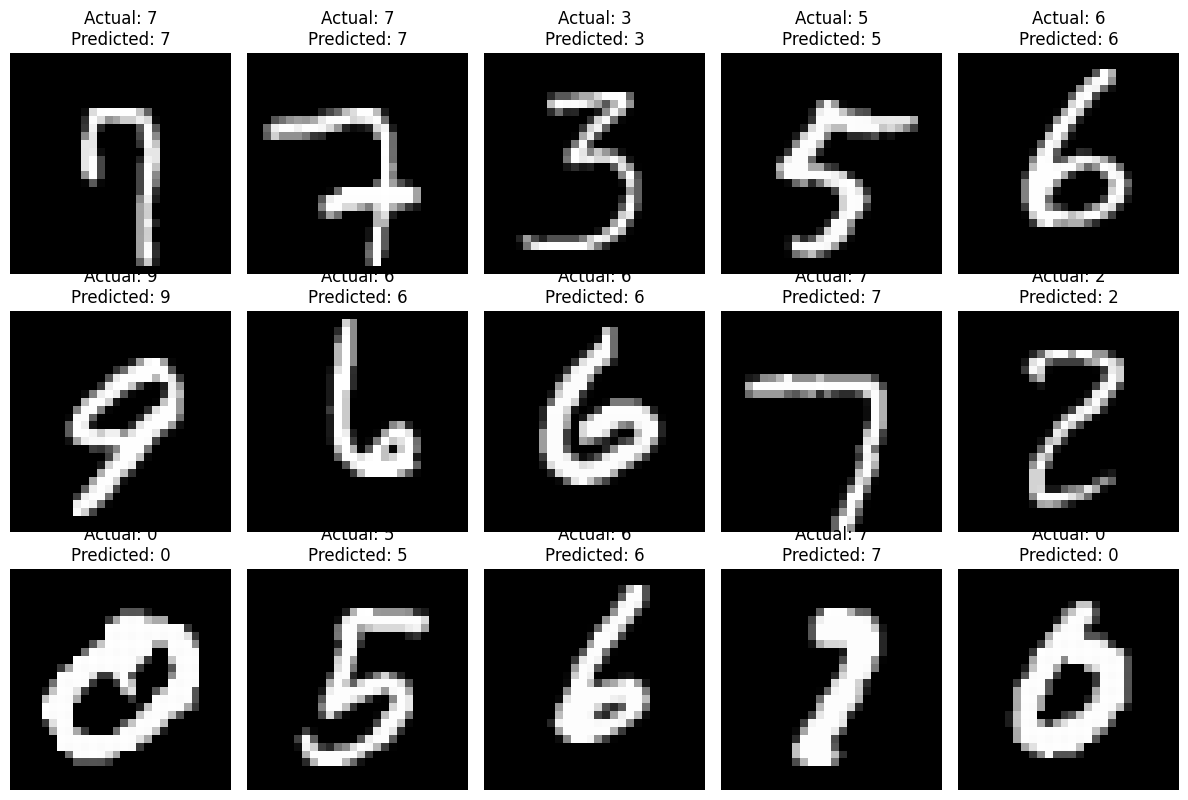

In [33]:
plt.figure(figsize=(12, 8))

for i in range(15):
    plt.subplot(3, 5, i + 1)

    plt.imshow(X_val[i].reshape(28, 28), cmap='gray')

    plt.title(
        f"Actual: {y_val[i]}\nPredicted: {y_pred[i]}"
    )

    plt.axis('off')

plt.tight_layout()
plt.show()

In [34]:
incorrect = np.where(y_pred != y_val)[0]

print("Number of incorrect predictions:", len(incorrect))
print("Number of correct predictions:", len(y_val) - len(incorrect))

Number of incorrect predictions: 347
Number of correct predictions: 11653


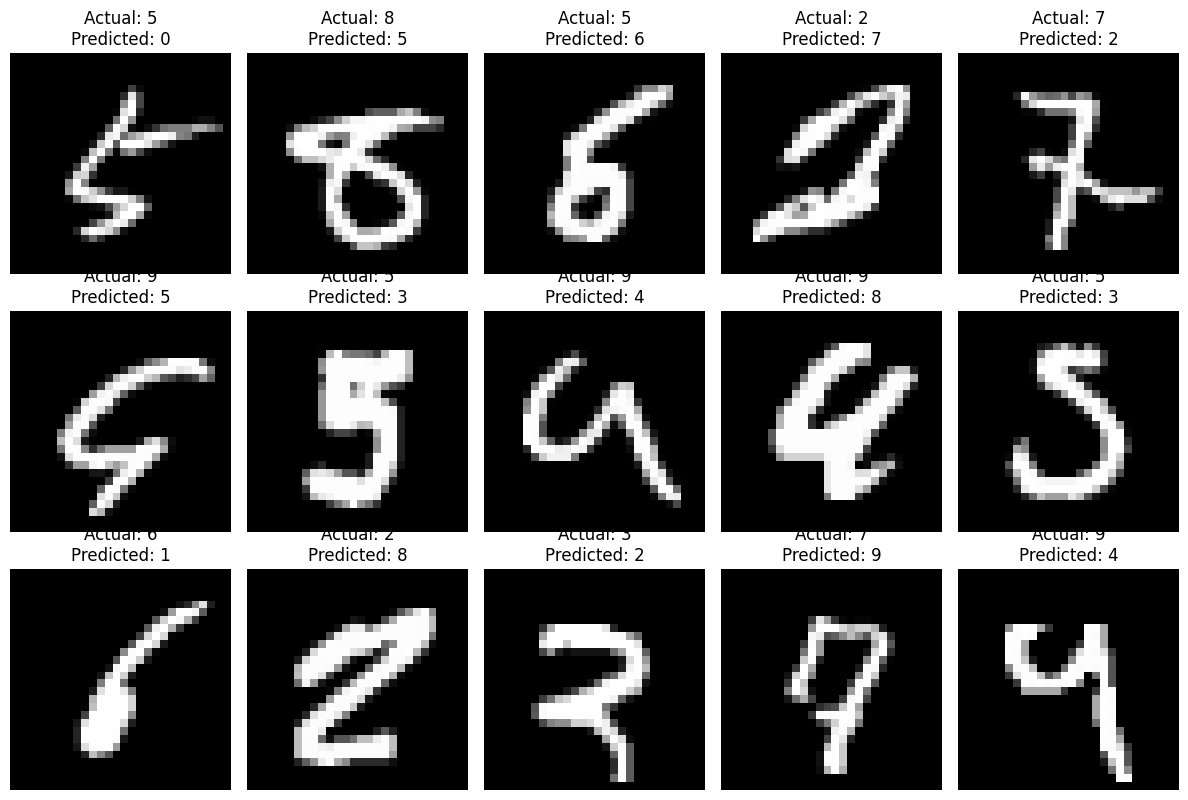

In [35]:
plt.figure(figsize=(12, 8))

for i, index in enumerate(incorrect[:15]):
    plt.subplot(3, 5, i + 1)

    plt.imshow(X_val[index].reshape(28, 28), cmap='gray')

    plt.title(
        f"Actual: {y_val[index]}\nPredicted: {y_pred[index]}"
    )

    plt.axis('off')

plt.tight_layout()
plt.show()

In [36]:
test_df = pd.read_csv('/content/mnist_test.csv')

print("Test Dataset Shape:", test_df.shape)
print("First 5 Rows:")
display(test_df.head())

/tmp/ipykernel_451/2909273288.py:1: DtypeWarning: Columns (0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,120,121,122,123,124,125,126,127,128,129,130,131,132,133,134,135,136,137,138,139,140,141,142,143,144,145,146,147,148,149,150,151,152,153,154,155,156,157,158,159,160,161,162,163,164,165,166,167,168,169,170,171,172,173,174,175,176,177,178,179,180,181,182,183,184,185,186,187,188,189,190,191,192,193,194,195,196,197,198,199,200,201,202,203,204,205,206,207,208,209,210,211,212,213,214,215,216,217,218,219,220,221,222,223,224,225,226,227,228,229,230,231,232,233,234,235,236,237,238,239,240,241,242,243,244,245,246,247,248,249,250,251,252,253,254,255,256,257,258,259,260,261,262

Test Dataset Shape: (10001, 785)
First 5 Rows:


,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,label,1x1,1x2,1x3,1x4,1x5,1x6,1x7,1x8,1x9,...,28x19,28x20,28x21,28x22,28x23,28x24,28x25,28x26,28x27,28x28
1,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [38]:
X_test = test_df.drop('label', axis=1).values
y_test = test_df['label'].values

# Remove the header row from X_test before converting to float
X_test = X_test[1:].astype('float32') / 255.0
# Remove the 'label' string from y_test and convert to integer
y_test = y_test[1:].astype(np.int32)

X_test = X_test.reshape(-1, 28, 28, 1)

print("Test Images:", X_test.shape)
print("Test Labels:", y_test.shape)

Test Images: (10000, 28, 28, 1)
Test Labels: (10000,)


In [39]:
test_loss, test_accuracy = model.evaluate(
    X_test,
    y_test,
    verbose=0
)

print("Final Test Results")
print("-------------------")
print("Test Loss     :", round(test_loss, 4))
print("Test Accuracy :", round(test_accuracy, 4))

Final Test Results
-------------------
Test Loss     : 18.7183
Test Accuracy : 0.9477


In [41]:
test_pred_prob = model.predict(X_test)

test_pred = np.argmax(test_pred_prob, axis=1)

print("Test predictions generated successfully!")

313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 23ms/step
Test predictions generated successfully!


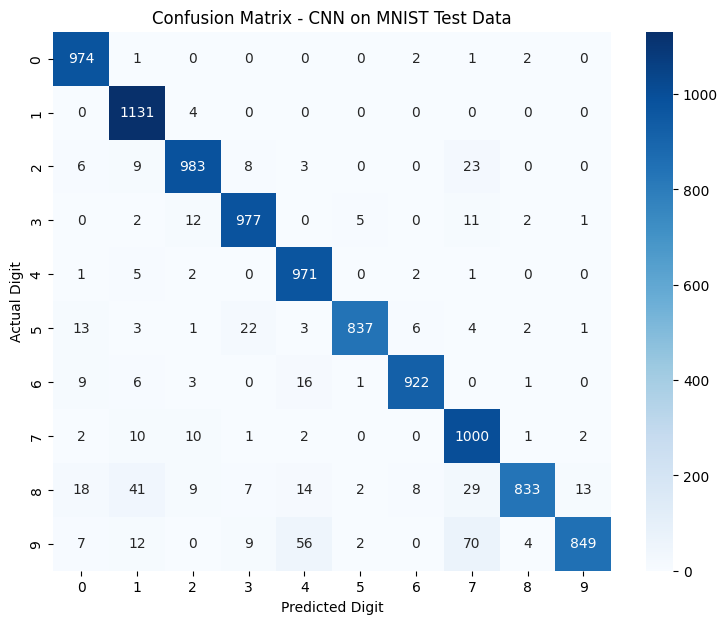

In [42]:
test_cm = confusion_matrix(y_test, test_pred)

plt.figure(figsize=(9, 7))

sns.heatmap(
    test_cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=range(10),
    yticklabels=range(10)
)

plt.xlabel('Predicted Digit')
plt.ylabel('Actual Digit')
plt.title('Confusion Matrix - CNN on MNIST Test Data')
plt.show()

In [43]:
print("Final Classification Report - CNN")
print("-----------------------------------")

print(
    classification_report(
        y_test,
        test_pred,
        target_names=[str(i) for i in range(10)]
    )
)

Final Classification Report - CNN
-----------------------------------
              precision    recall  f1-score   support

           0       0.95      0.99      0.97       980
           1       0.93      1.00      0.96      1135
           2       0.96      0.95      0.96      1032
           3       0.95      0.97      0.96      1010
           4       0.91      0.99      0.95       982
           5       0.99      0.94      0.96       892
           6       0.98      0.96      0.97       958
           7       0.88      0.97      0.92      1028
           8       0.99      0.86      0.92       974
           9       0.98      0.84      0.91      1009

    accuracy                           0.95     10000
   macro avg       0.95      0.95      0.95     10000
weighted avg       0.95      0.95      0.95     10000



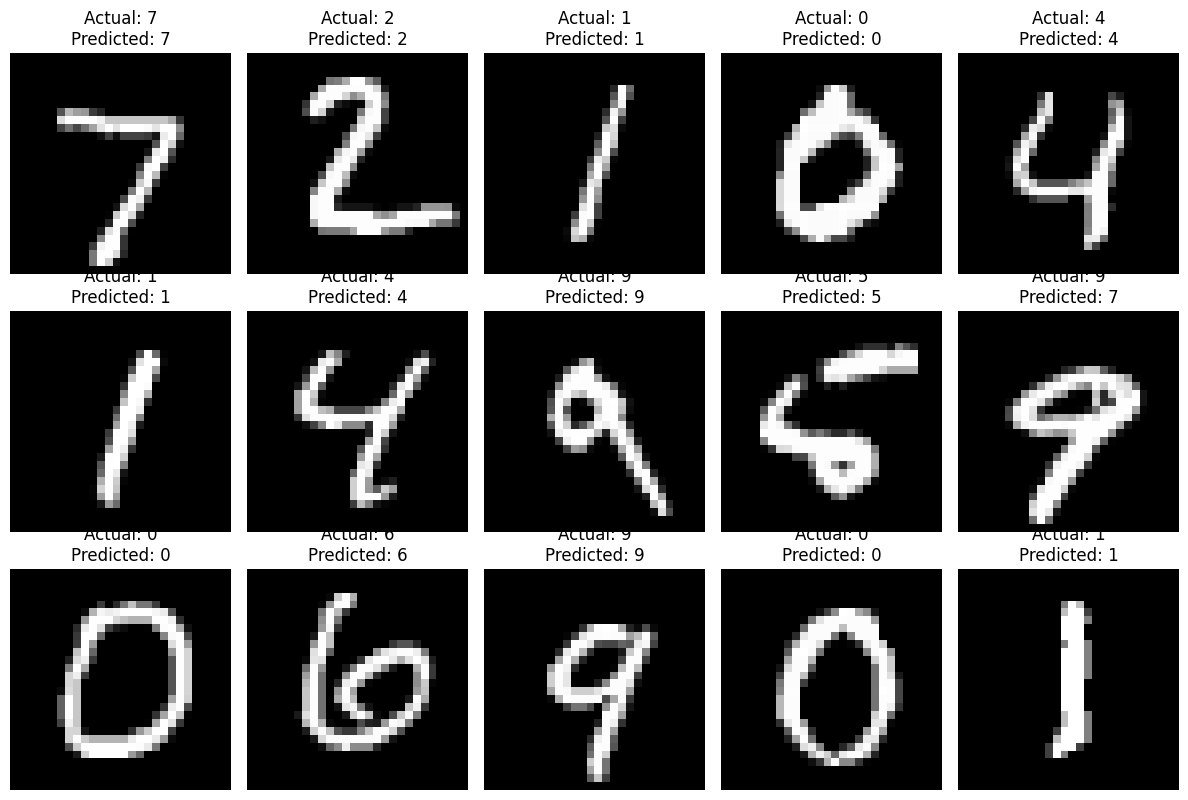

In [44]:
plt.figure(figsize=(12, 8))

for i in range(15):
    plt.subplot(3, 5, i + 1)

    plt.imshow(X_test[i].reshape(28, 28), cmap='gray')

    plt.title(
        f"Actual: {y_test[i]}\nPredicted: {test_pred[i]}"
    )

    plt.axis('off')

plt.tight_layout()
plt.show()

In [45]:
model.save('mnist_digit_recognition_cnn.keras')

print("CNN model saved successfully!")

CNN model saved successfully!


## Conclusion

In this project, a Convolutional Neural Network (CNN) was developed to
recognize handwritten digits using the MNIST dataset.

The project involved data exploration, image visualization, pixel
normalization, image reshaping, CNN model development, model training,
and performance evaluation.

The CNN was evaluated using accuracy, loss, confusion matrix, precision,
recall, and F1-score.

The model successfully learned important visual patterns from handwritten
digit images and was able to classify digits from 0 to 9.

This project provided practical experience in neural networks, image
preprocessing, CNN architecture, model training, and evaluation metrics.